# DeiT-Base/16 (distilled) — DR severity classifier (APTOS-2019)

**DeiT-Base/16 (distilled)** (`timm`, ImageNet weights) used as is: no layer is added or
removed. Same blocks as ViT plus a **distillation token**, and ImageNet weights obtained with a
CNN teacher. Fine-tuned here without a teacher, so the distillation token only carries its
pretrained behaviour; timm averages the two heads. Preprocessing and
split are **not** redone here: images are loaded from the preprocessed Kaggle dataset produced by
notebook `00` (FOV crop → resize 512×512 → PNG uint8, stratified split 2930 / 366 / 366).
Loss, optimiser, scheduler, early stopping and evaluation protocol are identical across all
models; only the architecture changes.

## Input data

Output of notebook `00`, attached as a Kaggle input. The folder is located automatically under
`/kaggle/input` (or set `CFG.PREP_DIR`):

```
<dataset>/
├── train/<id_code>.png   val/<id_code>.png   test/<id_code>.png
├── train.csv  val.csv  test.csv
└── preprocessing_config.json
```

## Outputs

```
/kaggle/working/
├── metrics.json                              # full run metrics
├── checkpoints/deit_base_distilled_patch16_224_s42.pth
└── results/
    ├── metrics/deit_base_distilled_patch16_224.json     # same content, file read by 08_model_comparison
    ├── metrics/deit_base_distilled_patch16_224_*.csv    # history, test predictions, summary
    └── figures/deit_base_distilled_patch16_224/*.png    # curves, confusion, ROC, Grad-CAM++
```

## Architecture

The standard `timm` model: patch embedding → 12 transformer blocks → class and distillation
tokens → two linear heads averaged at inference. The only change compared with ImageNet is unavoidable: `num_classes=5` gives the
classifier 5 outputs instead of 1000, so it is re-initialised while every other layer keeps its
pretrained weights. No extra dropout is added (timm default).

Loss: class-weighted cross-entropy.

## Explainability

Grad-CAM++ on the token sequence of the last transformer block (`blocks.11.norm1`), reshaped back
to a spatial grid. A transformer has no feature map, so this reshape is what makes the maps
comparable with the CNN ones.

## Reporting convention

Every metric — accuracy, precision, recall, F1, AUC, QWK — comes from the argmax of the model
output. The test set is evaluated exactly once.


## Cell 1 — Imports

In [1]:
import os, sys, json, random, time, warnings, hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

import timm

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             precision_recall_fscore_support, classification_report,
                             confusion_matrix, multilabel_confusion_matrix,
                             cohen_kappa_score, roc_curve, roc_auc_score)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings("ignore")
cv2.setNumThreads(0)

print(f"torch {torch.__version__} | timm {timm.__version__} | CUDA {torch.cuda.is_available()}")

torch 2.10.0+cu128 | timm 1.0.26 | CUDA True


## Cell 2 — Configuration and paths

DeiT-Base/16 has 86 M parameters and, at 512×512, processes 1024 patch tokens whose self-attention
cost grows with the square of that number. The micro-batch is therefore 4, and gradient
accumulation restores an effective batch of 16, as for the other backbones.

If the GPU runs out of memory, lower `BATCH_SIZE` to 2 and raise `ACCUM_STEPS` to 8: the gradient
is unchanged, since the loss is already divided by `ACCUM_STEPS`.


In [2]:
class CFG:
    # ---- Preprocessed data (output of notebook 00) --------------------------
    INPUT_ROOT = Path("/kaggle/input")
    PREP_DIR   = None             # None = auto-search for preprocessing_config.json
    SPLITS     = ("train", "val", "test")
    IMG_SIZE   = 512              # checked against preprocessing_config.json
    N_VAL      = 366
    N_TEST     = 366

    # ---- Model -------------------------------------------------------------
    BACKBONE   = "deit_base_distilled_patch16_224"   # timm identifier
    CAM_LAYER  = "blocks.11.norm1"   # last block's first LayerNorm: the Grad-CAM++ target
    FAMILY     = "ViT"
    N_CLASSES  = 5
    PRETRAINED = True

    # ---- Fine-tuning -------------------------------------------------------
    FREEZE_EPOCHS = 3             # everything frozen except the new classifier
    FREEZE_BN     = True          # frozen-phase BatchNorm kept in eval mode

    # ---- Optimisation ------------------------------------------------------
    LR             = 1e-4
    SCHED_FACTOR   = 0.5
    SCHED_PATIENCE = 3
    ES_PATIENCE    = 5
    MAX_EPOCHS     = 50
    CLASS_WEIGHT   = True
    SELECT_ON      = "val_qwk"    # checkpoint criterion: "val_qwk" | "val_loss"

    # ---- Explainability ----------------------------------------------------
    CAM_METHOD = "gradcam++"      # "gradcam++" | "gradcam"

    # ---- Implementation ----------------------------------------------------
    BATCH_SIZE  = 4               # micro-batch (86 M params, 1024 patch tokens at 512 px)
    ACCUM_STEPS = 4               # effective batch = BATCH_SIZE * ACCUM_STEPS = 16
    NUM_WORKERS = 2
    AMP         = True
    SEED        = 42
    DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CLASS_NAMES = ["No DR", "Mild DR", "Moderate DR", "Severe DR", "Proliferative DR"]

# Repository layout: checkpoints/ and results/{metrics,figures/<model>}/.
# 08_model_comparison reads results/metrics/<model>.json, hence MODEL_NAME = timm identifier.
CFG.MODEL_NAME = CFG.BACKBONE
CFG.WORK_DIR   = Path("/kaggle/working")
CFG.CKPT_PATH  = CFG.WORK_DIR / "checkpoints" / f"{CFG.MODEL_NAME}_s{CFG.SEED}.pth"
CFG.METRIC_DIR = CFG.WORK_DIR / "results" / "metrics"
CFG.FIG_DIR    = CFG.WORK_DIR / "results" / "figures" / CFG.MODEL_NAME
for _d in (CFG.CKPT_PATH.parent, CFG.METRIC_DIR, CFG.FIG_DIR):
    _d.mkdir(parents=True, exist_ok=True)


def _artifact(name: str) -> Path:
    """Non-figure run file, prefixed with the model name so all models share results/metrics."""
    return CFG.METRIC_DIR / f"{CFG.MODEL_NAME}_{name}"


print("Device     :", CFG.DEVICE)
print("Backbone   :", CFG.BACKBONE, "| seed :", CFG.SEED, "| selection :", CFG.SELECT_ON)
print(f"Batch      : {CFG.BATCH_SIZE} x {CFG.ACCUM_STEPS} accumulation = "
      f"{CFG.BATCH_SIZE * CFG.ACCUM_STEPS} effective")
print("Checkpoint :", CFG.CKPT_PATH)
print("Figures    :", CFG.FIG_DIR)
print("Metrics    :", CFG.METRIC_DIR)

Device     : cuda
Backbone   : deit_base_distilled_patch16_224 | seed : 42 | selection : val_qwk
Batch      : 4 x 4 accumulation = 16 effective
Checkpoint : /kaggle/working/checkpoints/deit_base_distilled_patch16_224_s42.pth
Figures    : /kaggle/working/results/figures/deit_base_distilled_patch16_224
Metrics    : /kaggle/working/results/metrics


## Cell 3 — Reproducibility

In [3]:
def seed_everything(seed: int = 42, deterministic: bool = True) -> None:
    """Seed every source of randomness. deterministic=True slows cuDNN down slightly."""
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
        torch.use_deterministic_algorithms(True, warn_only=True)
    else:
        torch.backends.cudnn.benchmark = True


def _worker_init(worker_id: int) -> None:
    s = CFG.SEED + worker_id
    np.random.seed(s)
    random.seed(s)


seed_everything(CFG.SEED)
g_loader = torch.Generator()
g_loader.manual_seed(CFG.SEED)
print("Seeds fixed to", CFG.SEED)

Seeds fixed to 42


## Cell 4 — Loading the preprocessed splits

No re-splitting: the three CSV files from notebook `00` are authoritative, so every model is
evaluated on exactly the same 366 test images. A SHA-1 fingerprint of each split's `id_code`s is
printed and saved to `metrics.json` to verify this across notebooks.

Image lookup: Kaggle may extract archives into a sub-folder. Images are searched next to the CSV
files first, then by file name — requiring the parent folder to be named after the split, otherwise
a raw image from `train_images/` (same `id_code`) would be picked up by mistake.

In [4]:
def _locate_prep_dirs(search_root: Path) -> list:
    """Folders holding preprocessing_config.json and the three split CSV files."""
    return sorted(p.parent for p in search_root.rglob("preprocessing_config.json")
                  if all((p.parent / f"{s}.csv").exists() for s in CFG.SPLITS))


def _resolve_prep_dir() -> Path:
    if CFG.PREP_DIR is not None:
        return Path(CFG.PREP_DIR)
    cands = _locate_prep_dirs(CFG.INPUT_ROOT)
    if not cands:
        raise FileNotFoundError(f"Notebook 00 output not found under {CFG.INPUT_ROOT}")
    # Notebook 00 writes the CSV/config files to two places: several identical candidates are
    # expected, different splits are not.
    ref = {s: set(pd.read_csv(cands[0] / f"{s}.csv")["id_code"]) for s in CFG.SPLITS}
    for c in cands[1:]:
        if any(set(pd.read_csv(c / f"{s}.csv")["id_code"]) != ref[s] for s in CFG.SPLITS):
            raise RuntimeError(f"Different splits in {cands[0]} and {c}: set CFG.PREP_DIR")
    return cands[0]


def _locate_img_dir(split: str, first_id: str, prep_dir: Path) -> Path:
    direct = prep_dir / split
    if (direct / f"{first_id}.png").exists():
        return direct
    hit = next((p for p in CFG.INPUT_ROOT.rglob(f"{first_id}.png") if p.parent.name == split), None)
    if hit is None:
        raise FileNotFoundError(f"{first_id}.png not found in any '{split}/' folder")
    return hit.parent


def _load_split(split: str, prep_dir: Path) -> pd.DataFrame:
    frame = pd.read_csv(prep_dir / f"{split}.csv")
    img_dir = _locate_img_dir(split, frame["id_code"].iloc[0], prep_dir)
    frame["path"] = [str(img_dir / f"{i}.png") for i in frame["id_code"]]

    missing = [p for p in frame["path"] if not os.path.exists(p)]
    assert not missing, f"{split}: {len(missing)} missing images, e.g. {missing[:2]}"

    # A single read is enough to catch a raw image or a wrong resolution.
    h, w, c = cv2.imread(frame["path"].iloc[0]).shape
    assert (h, w, c) == (CFG.IMG_SIZE, CFG.IMG_SIZE, 3), f"{split}: image {w}x{h}x{c}"
    print(f"{split:5s} : {len(frame):4d} images  <- {img_dir}")
    return frame.reset_index(drop=True)


def _split_sha1(frame: pd.DataFrame) -> str:
    """Row-order independent fingerprint of a split."""
    return hashlib.sha1("\n".join(sorted(frame["id_code"])).encode()).hexdigest()[:12]


# 1. locate the dataset and read the preprocessing configuration
prep_dir = _resolve_prep_dir()
with open(prep_dir / "preprocessing_config.json") as f:
    prep_cfg = json.load(f)
print("Preprocessed data :", prep_dir)
print(json.dumps(prep_cfg, indent=2, ensure_ascii=False))
assert prep_cfg["img_size"] == CFG.IMG_SIZE, (prep_cfg["img_size"], CFG.IMG_SIZE)

# 2. load the three splits
df_train, df_val, df_test = (_load_split(s, prep_dir) for s in CFG.SPLITS)
assert (len(df_val), len(df_test)) == (CFG.N_VAL, CFG.N_TEST), (len(df_val), len(df_test))
splits = {"train": df_train, "val": df_val, "test": df_test}

# 3. class distribution, leakage check, fingerprints
split_table = pd.DataFrame({
    name: d["diagnosis"].value_counts().reindex(range(CFG.N_CLASSES), fill_value=0)
    for name, d in splits.items()
})
split_table.index = CLASS_NAMES
split_table.loc["TOTAL"] = split_table.sum()
print()
print(split_table.to_string())

ids = [set(d["id_code"]) for d in splits.values()]
assert not (ids[0] & ids[1]) and not (ids[0] & ids[2]) and not (ids[1] & ids[2]), "split leakage"
split_sha1 = {name: _split_sha1(d) for name, d in splits.items()}
print("\nNo overlap between train / val / test.")
print("SHA-1 :", split_sha1)

Preprocessed data : /kaggle/input/datasets/fatmagaida/aptos-prerocessed/aptos_preprocessed
{
  "img_size": 512,
  "fov_tol": 7,
  "min_area_ratio": 0.05,
  "interpolation": "area",
  "padding": "none",
  "normalization": "x/127.5 - 1.0 applied at load time, range [-1, 1]",
  "seed": 42,
  "val_n": 366,
  "test_n": 366,
  "train_n": 2930,
  "split_level": "image (APTOS ne fournit pas d'identifiant patient)"
}
train : 2930 images  <- /kaggle/input/datasets/fatmagaida/aptos-prerocessed/aptos_preprocessed/train
val   :  366 images  <- /kaggle/input/datasets/fatmagaida/aptos-prerocessed/aptos_preprocessed/val
test  :  366 images  <- /kaggle/input/datasets/fatmagaida/aptos-prerocessed/aptos_preprocessed/test

                  train  val  test
No DR              1444  180   181
Mild DR             296   37    37
Moderate DR         799  100   100
Severe DR           155   19    19
Proliferative DR    236   30    29
TOTAL              2930  366   366

No overlap between train / val / test.
SH

## Cell 5 — Dataset, augmentation and DataLoaders

PNGs are already cropped and resized: the Dataset only reads the image, applies random flips
(training set only, redrawn at every epoch) and normalises to [−1, 1] at load time. Validation and
test images are never augmented.

In [5]:
def normalize_pm1(img_rgb_uint8: np.ndarray) -> np.ndarray:
    """Normalisation to [-1, 1]."""
    return img_rgb_uint8.astype(np.float32) / 127.5 - 1.0


def denormalize(t: torch.Tensor) -> np.ndarray:
    """CHW tensor in [-1, 1] -> HWC uint8 RGB image, for displaying the maps."""
    return (((t.detach().cpu().numpy().transpose(1, 2, 0) + 1.0) * 127.5)
            .clip(0, 255).astype(np.uint8))


def augment_flips(img: np.ndarray, p: float = 0.5) -> np.ndarray:
    """Random horizontal and vertical flips."""
    if random.random() < p:
        img = img[:, ::-1]
    if random.random() < p:
        img = img[::-1, :]
    return np.ascontiguousarray(img)


class APTOSDataset(Dataset):
    """Returns (CHW float32 tensor in [-1, 1], int64 label)."""

    def __init__(self, frame: pd.DataFrame, train: bool = False):
        self.paths  = frame["path"].tolist()
        self.labels = frame["diagnosis"].astype(np.int64).tolist()
        self.train  = train

    def __len__(self) -> int:
        return len(self.paths)

    def __getitem__(self, i: int):
        img = cv2.imread(self.paths[i], cv2.IMREAD_COLOR)
        if img is None:
            raise FileNotFoundError(self.paths[i])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)     # PNGs were written as BGR by OpenCV
        if self.train:
            img = augment_flips(img)
        img = normalize_pm1(img)
        return torch.from_numpy(np.ascontiguousarray(img.transpose(2, 0, 1))), self.labels[i]


ds_train = APTOSDataset(df_train, train=True)
ds_val   = APTOSDataset(df_val,   train=False)
ds_test  = APTOSDataset(df_test,  train=False)

common = dict(num_workers=CFG.NUM_WORKERS, pin_memory=True,
              persistent_workers=CFG.NUM_WORKERS > 0, worker_init_fn=_worker_init)

dl_train = DataLoader(ds_train, batch_size=CFG.BATCH_SIZE, shuffle=True,
                      drop_last=False, generator=g_loader, **common)
dl_val   = DataLoader(ds_val,   batch_size=CFG.BATCH_SIZE, shuffle=False, **common)
dl_test  = DataLoader(ds_test,  batch_size=CFG.BATCH_SIZE, shuffle=False, **common)

xb, yb = next(iter(dl_train))
print(f"Batch : {tuple(xb.shape)} {xb.dtype}  range [{xb.min():.2f}, {xb.max():.2f}]")

Batch : (4, 3, 512, 512) torch.float32  range [-1.00, 1.00]


## Cell 6 — Architecture: DeiT-Base/16 (distilled)

`timm.create_model(..., num_classes=5, img_size=CFG.IMG_SIZE)` builds the standard architecture and
loads the ImageNet weights for every layer except the final heads, whose shape changes from
`Linear(768, 1000)` to `Linear(768, 5)` and which are therefore freshly initialised. The position
embeddings, pretrained for a 14×14 patch grid at 224 px, are **interpolated** by timm to the grid
used here. Nothing else is added, removed or replaced.

The image is cut into 16×16 patches, so a 512 px input gives a 32×32 grid of patch tokens, plus 1
class token and 1 distillation token (2 prefix tokens). A distilled DeiT has **two** heads and timm
averages their logits, so `get_classifier()` returns a tuple and both are unfrozen together.

Grad-CAM++ target layer: `blocks.11.norm1`, the first LayerNorm of the last transformer block. The
very last LayerNorm (`norm`) sits after the residual sum of every block and gives much flatter
maps. `FREEZE_BN` has no effect here: a transformer uses LayerNorm, which has no running statistics
to protect during the frozen phase.


In [6]:
model = timm.create_model(CFG.BACKBONE, pretrained=CFG.PRETRAINED,
                          num_classes=CFG.N_CLASSES,
                          img_size=CFG.IMG_SIZE).to(CFG.DEVICE)

def classifier_modules(m: nn.Module) -> list:
    """Final layer(s). A distilled DeiT has two heads, so timm returns a tuple."""
    head = m.get_classifier()
    return list(head) if isinstance(head, (tuple, list)) else [head]


classifier = classifier_modules(model)
cfg_name = model.default_cfg["classifier"]
classifier_name = "+".join(cfg_name) if isinstance(cfg_name, (tuple, list)) else cfg_name

# Token layout, needed to turn the sequence back into a grid for Grad-CAM++ (Cell 18).
N_PREFIX = model.num_prefix_tokens          # class token + distillation token
GRID_H, GRID_W = model.patch_embed.grid_size

# Explicit target layer: a generic "last block" fallback would silently pick a
# post-residual map, which is much flatter.
cam_layer = model.get_submodule(CFG.CAM_LAYER)

n_tot  = sum(p.numel() for p in model.parameters())
n_clf = sum(p.numel() for c in classifier for p in c.parameters())

print(f"Classifier       : {classifier_name} = {classifier}")
print(f"Features         : {model.num_features}")
print(f"Patch grid       : {GRID_H} x {GRID_W} = {GRID_H * GRID_W} patch tokens "
      f"+ {N_PREFIX} prefix token(s)")
print(f"Parameters total : {n_tot:,}  |  classifier : {n_clf:,}  |  rest : {n_tot - n_clf:,}")
print(f"CAM target layer : {CFG.CAM_LAYER} ({type(cam_layer).__name__})")

_seq = {}
_h = cam_layer.register_forward_hook(lambda m_, i_, o_: _seq.setdefault("o", o_))
with torch.no_grad():
    _out = model(torch.zeros(2, 3, CFG.IMG_SIZE, CFG.IMG_SIZE, device=CFG.DEVICE))
_h.remove()
assert _seq["o"].shape[1] == GRID_H * GRID_W + N_PREFIX, _seq["o"].shape
print(f"Token sequence   : {tuple(_seq['o'].shape)}")
print("Output :", tuple(_out.shape))
del _out, _seq


model.safetensors:   0%|          | 0.00/349M [00:00<?, ?B/s]

Classifier       : head+head_dist = [Linear(in_features=768, out_features=5, bias=True), Linear(in_features=768, out_features=5, bias=True)]
Features         : 768
Patch grid       : 32 x 32 = 1024 patch tokens + 2 prefix token(s)
Parameters total : 86,443,786  |  classifier : 7,690  |  rest : 86,436,096
CAM target layer : blocks.11.norm1 (LayerNorm)
Token sequence   : (2, 1026, 768)
Output : (2, 5)


## Cell 7 — Class weights

scikit-learn "balanced" formula, `w_c = N / (K · n_c)`, computed **on the training set only**.

In [7]:
classes = np.arange(CFG.N_CLASSES)
cw = compute_class_weight("balanced", classes=classes, y=df_train["diagnosis"].values)
class_weights = torch.tensor(cw, dtype=torch.float32, device=CFG.DEVICE)

print(pd.DataFrame({"class": CLASS_NAMES,
                    "n_train": df_train["diagnosis"].value_counts().reindex(classes).values,
                    "weight": cw.round(4)}).to_string(index=False))

           class  n_train  weight
           No DR     1444  0.4058
         Mild DR      296  1.9797
     Moderate DR      799  0.7334
       Severe DR      155  3.7806
Proliferative DR      236  2.4831


## Cell 8 — Loss, optimiser, scheduler

Weighted cross-entropy averaged as `mean(w_y · CE)` over the batch (Keras `class_weight`
semantics). PyTorch's default `reduction="mean"` would instead divide by `Σ w_y`, which changes the
effective learning rate from batch to batch depending on its class mix. `[IMPL]`

A single Adam optimiser covers every parameter: freezing is done through `requires_grad`, so Adam
and the scheduler do not have to be re-created when the network is unfrozen.

In [8]:
class WeightedCE(nn.Module):
    """mean(w_y * CE) over the batch."""

    def __init__(self, weight: torch.Tensor = None):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(weight=weight, reduction="none")

    def forward(self, logits: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        return self.ce(logits, y).mean()


criterion = WeightedCE(class_weights if CFG.CLASS_WEIGHT else None)
optimizer = torch.optim.Adam(model.parameters(), lr=CFG.LR)
scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=CFG.SCHED_FACTOR,
                              patience=CFG.SCHED_PATIENCE)                 # on val loss
scaler = torch.amp.GradScaler("cuda", enabled=CFG.AMP and CFG.DEVICE.type == "cuda")


def set_trainable(model: nn.Module, phase: str) -> None:
    """phase='frozen': only the new classifier is trained; 'full': the whole network."""
    for p in model.parameters():
        p.requires_grad = phase == "full"
    for c in classifier_modules(model):          # a distilled DeiT has two heads
        for p in c.parameters():
            p.requires_grad = True


print(f"Loss : weighted CE (class weights = {CFG.CLASS_WEIGHT})")
print(f"Optimiser : Adam lr = {CFG.LR} | ReduceLROnPlateau(factor={CFG.SCHED_FACTOR}, "
      f"patience={CFG.SCHED_PATIENCE})")

Loss : weighted CE (class weights = True)
Optimiser : Adam lr = 0.0001 | ReduceLROnPlateau(factor=0.5, patience=3)


## Cell 9 — Training loop and inference

During the frozen phase, BatchNorm layers are switched to `eval()` so their pretrained running
statistics are not overwritten by the first classifier-only epochs.

The loss is divided by `ACCUM_STEPS` before back-propagation, so the accumulated gradient over
`ACCUM_STEPS` micro-batches equals the mean over a full batch, not its sum.

In [9]:
def train_one_epoch(model, loader, criterion, optimizer, scaler, phase: str):
    model.train()
    if phase == "frozen" and CFG.FREEZE_BN:
        for m in model.modules():
            if isinstance(m, nn.BatchNorm2d):
                m.eval()

    tot_loss, n = 0.0, 0
    preds, targets = [], []
    optimizer.zero_grad(set_to_none=True)

    for step, (x, y) in enumerate(loader, 1):
        x = x.to(CFG.DEVICE, non_blocking=True)
        y = y.to(CFG.DEVICE, non_blocking=True)
        with torch.amp.autocast("cuda", enabled=scaler.is_enabled()):
            logits = model(x)
            loss = criterion(logits, y)
        scaler.scale(loss / CFG.ACCUM_STEPS).backward()

        if step % CFG.ACCUM_STEPS == 0 or step == len(loader):
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        bs = y.size(0)
        tot_loss += loss.item() * bs
        preds.append(logits.argmax(1).cpu().numpy())
        targets.append(y.cpu().numpy())
        n += bs
    return tot_loss / n, accuracy_score(np.concatenate(targets), np.concatenate(preds))


@torch.no_grad()
def evaluate(model, loader, criterion=None):
    """Returns (loss, accuracy, softmax probabilities, labels)."""
    model.eval()
    tot_loss, n = 0.0, 0
    probs, targets = [], []
    for x, y in loader:
        x = x.to(CFG.DEVICE, non_blocking=True)
        y = y.to(CFG.DEVICE, non_blocking=True)
        with torch.amp.autocast("cuda", enabled=CFG.AMP and CFG.DEVICE.type == "cuda"):
            logits = model(x)
            if criterion is not None:
                tot_loss += criterion(logits, y).item() * y.size(0)
        probs.append(F.softmax(logits.float(), dim=1).cpu().numpy())
        targets.append(y.cpu().numpy())
        n += y.size(0)

    probs, targets = np.concatenate(probs), np.concatenate(targets)
    loss = tot_loss / n if criterion is not None else float("nan")
    return loss, accuracy_score(targets, probs.argmax(1)), probs, targets


print("Training and evaluation functions ready.")

Training and evaluation functions ready.


## Cell 10 — Early stopping, checkpointing, training

3 epochs with only the new classifier trainable (the pretrained layers are frozen while the
randomly initialised classifier settles), then the whole network is unfrozen. ReduceLROnPlateau and early stopping
(patience 5) both monitor the **validation loss**. The saved checkpoint is selected on
`CFG.SELECT_ON` — by default the validation QWK of the argmax prediction — so the model kept is not
necessarily the one at the last epoch.

In [10]:
class EarlyStopping:
    """Stops when the validation loss has not improved for `patience` epochs."""

    def __init__(self, patience: int = CFG.ES_PATIENCE, min_delta: float = 0.0):
        self.patience, self.min_delta = patience, min_delta
        self.best, self.counter, self.stop = float("inf"), 0, False

    def step(self, val_loss: float) -> bool:
        improved = val_loss < self.best - self.min_delta
        if improved:
            self.best, self.counter = val_loss, 0
        else:
            self.counter += 1
            self.stop = self.counter >= self.patience
        return improved


# Higher is better for every entry.
_SELECT_SCORE = {
    "val_qwk":  lambda val_loss, val_qwk: val_qwk,
    "val_loss": lambda val_loss, val_qwk: -val_loss,
}
select_score = _SELECT_SCORE[CFG.SELECT_ON]

seed_everything(CFG.SEED)
stopper = EarlyStopping()
history = []
best_score, best_epoch = -float("inf"), -1
t_start = time.time()

for epoch in range(1, CFG.MAX_EPOCHS + 1):
    phase = "frozen" if epoch <= CFG.FREEZE_EPOCHS else "full"
    if epoch in (1, CFG.FREEZE_EPOCHS + 1):
        set_trainable(model, phase)
        n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"--- phase '{phase}': {n_trainable:,} trainable parameters ---")

    lr_now = optimizer.param_groups[0]["lr"]
    tr_loss, tr_acc = train_one_epoch(model, dl_train, criterion, optimizer, scaler, phase)
    va_loss, va_acc, va_prob, va_y = evaluate(model, dl_val, criterion)
    va_qwk = cohen_kappa_score(va_y, va_prob.argmax(1), weights="quadratic")

    scheduler.step(va_loss)
    es_improved = stopper.step(va_loss)

    current = select_score(va_loss, va_qwk)
    selected = current > best_score
    if selected:
        best_score, best_epoch = current, epoch
        torch.save({"epoch": epoch, "state_dict": model.state_dict(), "backbone": CFG.BACKBONE,
                    "val_loss": va_loss, "val_acc": va_acc, "val_qwk": va_qwk}, CFG.CKPT_PATH)

    history.append(dict(epoch=epoch, phase=phase, lr=lr_now,
                        train_loss=tr_loss, train_acc=tr_acc,
                        val_loss=va_loss, val_acc=va_acc, val_qwk=va_qwk))
    print(f"Epoch {epoch:02d} [{phase:6s}] lr={lr_now:.2e} | "
          f"train {tr_loss:.4f}/{tr_acc:.4f} | val {va_loss:.4f}/{va_acc:.4f} | "
          f"QWK {va_qwk:.4f}"
          f"{'  <- saved' if selected else ''}"
          f"{'' if es_improved else f'  (patience {stopper.counter}/{CFG.ES_PATIENCE})'}")

    if stopper.stop:
        print(f"\nEarly stopping at epoch {epoch}. Selected checkpoint: epoch {best_epoch}.")
        break

hist = pd.DataFrame(history)
train_minutes = (time.time() - t_start) / 60
print(f"\nDuration: {train_minutes:.1f} min over {len(hist)} epochs")

--- phase 'frozen': 7,690 trainable parameters ---
Epoch 01 [frozen] lr=1.00e-04 | train 1.4580/0.4819 | val 1.3484/0.5246 | QWK 0.6221  <- saved
Epoch 02 [frozen] lr=1.00e-04 | train 1.2069/0.6638 | val 1.2096/0.6585 | QWK 0.7463  <- saved
Epoch 03 [frozen] lr=1.00e-04 | train 1.0930/0.7003 | val 1.1416/0.6421 | QWK 0.7500  <- saved
--- phase 'full': 86,443,786 trainable parameters ---
Epoch 04 [full  ] lr=1.00e-04 | train 1.1238/0.6369 | val 0.9794/0.7459 | QWK 0.8331  <- saved
Epoch 05 [full  ] lr=1.00e-04 | train 0.8940/0.7468 | val 0.8755/0.6831 | QWK 0.8732  <- saved
Epoch 06 [full  ] lr=1.00e-04 | train 0.7947/0.7713 | val 0.8756/0.7705 | QWK 0.8218  (patience 1/5)
Epoch 07 [full  ] lr=1.00e-04 | train 0.6972/0.7973 | val 0.8396/0.7732 | QWK 0.8626
Epoch 08 [full  ] lr=1.00e-04 | train 0.6333/0.8133 | val 0.9918/0.7268 | QWK 0.8195  (patience 1/5)
Epoch 09 [full  ] lr=1.00e-04 | train 0.5662/0.8358 | val 0.8705/0.7842 | QWK 0.8948  <- saved  (patience 2/5)
Epoch 10 [full  ] lr=1

## Cell 11 — Training curves

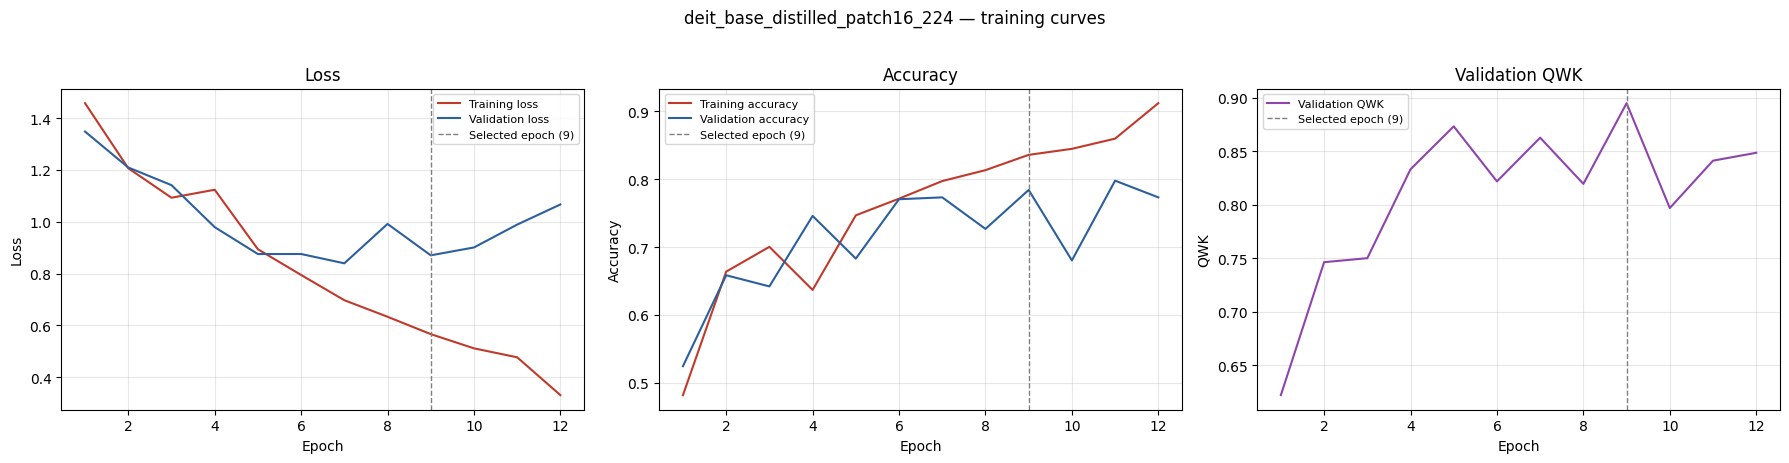

 epoch  phase     lr  train_loss  train_acc  val_loss  val_acc  val_qwk
     1 frozen 0.0001      1.4580     0.4819    1.3484   0.5246   0.6221
     2 frozen 0.0001      1.2069     0.6638    1.2096   0.6585   0.7463
     3 frozen 0.0001      1.0930     0.7003    1.1416   0.6421   0.7500
     4   full 0.0001      1.1238     0.6369    0.9794   0.7459   0.8331
     5   full 0.0001      0.8940     0.7468    0.8755   0.6831   0.8732
     6   full 0.0001      0.7947     0.7713    0.8756   0.7705   0.8218
     7   full 0.0001      0.6972     0.7973    0.8396   0.7732   0.8626
     8   full 0.0001      0.6333     0.8133    0.9918   0.7268   0.8195
     9   full 0.0001      0.5662     0.8358    0.8705   0.7842   0.8948
    10   full 0.0001      0.5113     0.8447    0.9009   0.6803   0.7969
    11   full 0.0001      0.4767     0.8597    0.9892   0.7978   0.8412
    12   full 0.0000      0.3307     0.9119    1.0669   0.7732   0.8485


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

axes[0].plot(hist["epoch"], hist["train_loss"], color="#c0392b", label="Training loss")
axes[0].plot(hist["epoch"], hist["val_loss"], color="#2c5f9e", label="Validation loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].set_title("Loss")

axes[1].plot(hist["epoch"], hist["train_acc"], color="#c0392b", label="Training accuracy")
axes[1].plot(hist["epoch"], hist["val_acc"], color="#2c5f9e", label="Validation accuracy")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].set_title("Accuracy")

axes[2].plot(hist["epoch"], hist["val_qwk"], color="#8e44ad", label="Validation QWK")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("QWK"); axes[2].set_title("Validation QWK")

for ax in axes:
    ax.axvline(best_epoch, ls="--", c="gray", lw=1, label=f"Selected epoch ({best_epoch})")
    ax.legend(fontsize=8); ax.grid(alpha=.3)

plt.suptitle(f"{CFG.BACKBONE} — training curves", y=1.02)
plt.tight_layout()
plt.savefig(CFG.FIG_DIR / "training_curves.png", dpi=200, bbox_inches="tight")
plt.show()

hist.to_csv(_artifact("training_history.csv"), index=False)
print(hist.round(4).to_string(index=False))

## Cell 12 — Restoring the best checkpoint

In [12]:
ckpt = torch.load(CFG.CKPT_PATH, map_location=CFG.DEVICE, weights_only=False)
model.load_state_dict(ckpt["state_dict"])
model.to(CFG.DEVICE).eval()
print(f"Checkpoint restored: epoch {ckpt['epoch']} | val_loss {ckpt['val_loss']:.4f} | "
      f"val_acc {ckpt['val_acc']:.4f} | val_QWK {ckpt['val_qwk']:.4f}")

Checkpoint restored: epoch 9 | val_loss 0.8705 | val_acc 0.7842 | val_QWK 0.8948


## Cell 13 — Test set evaluation

The test set is evaluated **exactly once**, without test-time augmentation. All metrics below are
computed from `y_pred = argmax(y_prob)`.

In [13]:
test_loss, test_acc, y_prob, y_true = evaluate(model, dl_test, criterion)
y_pred = y_prob.argmax(1)

acc       = accuracy_score(y_true, y_pred)
f1_macro  = f1_score(y_true, y_pred, average="macro")
qwk       = cohen_kappa_score(y_true, y_pred, weights="quadratic")
kappa_lin = cohen_kappa_score(y_true, y_pred, weights="linear")

print(f"Test : n = {len(y_true)} | loss {test_loss:.4f}")
print(f"  Accuracy       : {acc*100:.2f} %")
print(f"  F1 macro       : {f1_macro:.4f}")
print(f"  QWK            : {qwk:.4f}")
print(f"  Linear kappa   : {kappa_lin:.4f}")

pred_df = pd.DataFrame({
    "id_code": df_test["id_code"].values,
    "true": y_true, "pred": y_pred,
    **{f"prob_{i}": y_prob[:, i] for i in range(CFG.N_CLASSES)},
})
pred_df.to_csv(_artifact("test_predictions.csv"), index=False)
pred_df.head()

Test : n = 366 | loss 0.8413
  Accuracy       : 79.23 %
  F1 macro       : 0.6466
  QWK            : 0.9049
  Linear kappa   : 0.8235


,id_code,true,pred,prob_0,prob_1,prob_2,prob_3,prob_4
0,ce754234d760,0,0,0.994837,0.004252,0.000849,0.000009,0.000052
1,668e853258cd,2,2,0.008932,0.020971,0.788478,0.155109,0.026510
2,4384fa687afa,2,1,0.004348,0.398374,0.277567,0.184674,0.135036
3,4d3de40ced3a,0,0,0.999588,0.000362,0.000046,0.000001,0.000003
4,26453eb7e989,2,2,0.000223,0.002479,0.506813,0.476107,0.014377


## Cell 14 — Confusion matrices

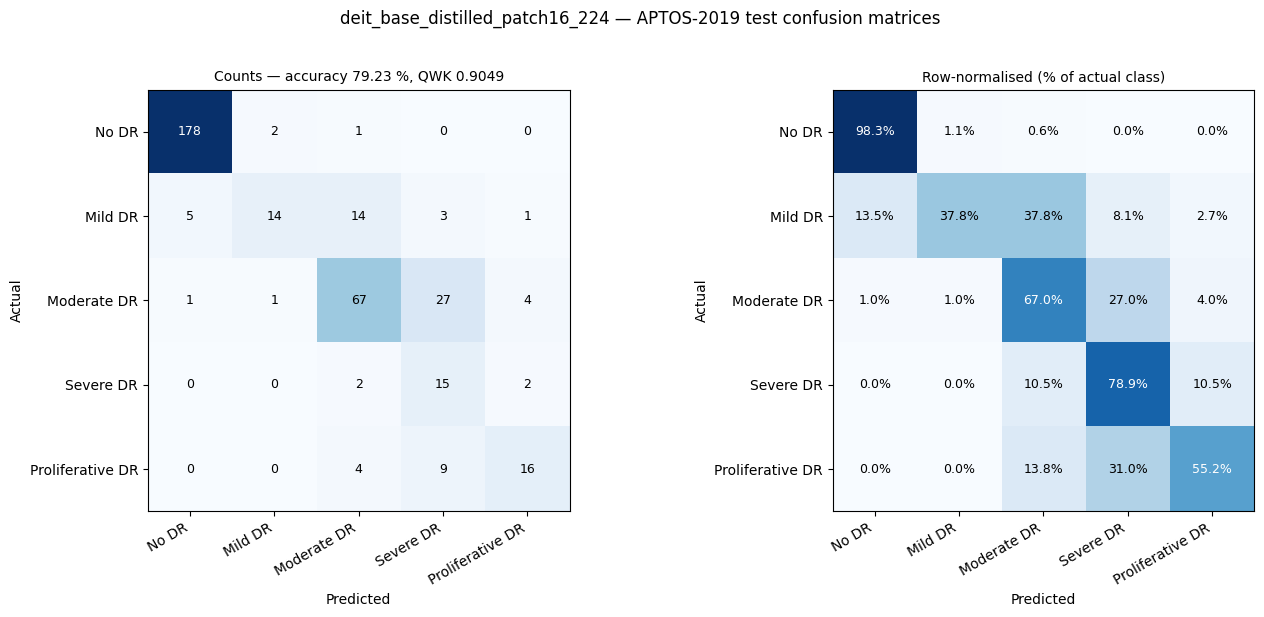

In [14]:
cm     = confusion_matrix(y_true, y_pred, labels=range(CFG.N_CLASSES))
cm_pct = confusion_matrix(y_true, y_pred, labels=range(CFG.N_CLASSES), normalize="true") * 100


def _plot_cm(ax, m: np.ndarray, title: str, pct: bool = False) -> None:
    """Display only: m is already computed by confusion_matrix."""
    ax.imshow(m, cmap="Blues")
    for i in range(CFG.N_CLASSES):
        for j in range(CFG.N_CLASSES):
            v = m[i, j]
            ax.text(j, i, f"{v:.1f}%" if pct else f"{int(v)}", ha="center", va="center",
                    fontsize=9, color="white" if v > m.max() * 0.55 else "black")
    ax.set_xticks(range(CFG.N_CLASSES)); ax.set_yticks(range(CFG.N_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha="right")
    ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual"); ax.set_title(title, fontsize=10)


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
_plot_cm(axes[0], cm,     f"Counts — accuracy {acc*100:.2f} %, QWK {qwk:.4f}")
_plot_cm(axes[1], cm_pct, "Row-normalised (% of actual class)", pct=True)
plt.suptitle(f"{CFG.BACKBONE} — APTOS-2019 test confusion matrices", y=1.02)
plt.tight_layout()
plt.savefig(CFG.FIG_DIR / "confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

## Cell 15 — One-vs-rest ROC curves and AUC

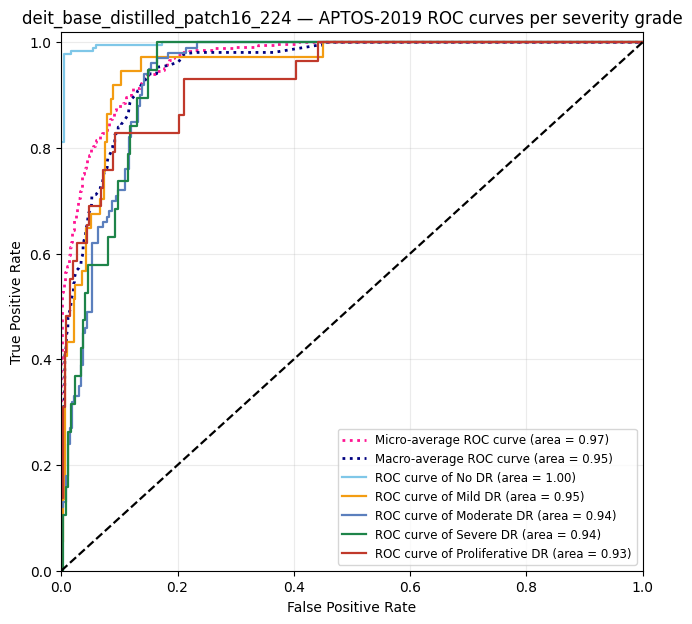

AUC OvR macro 0.9513 | weighted 0.9683 | micro 0.9659


In [15]:
y_bin = label_binarize(y_true, classes=range(CFG.N_CLASSES))

# 1. Areas: all computed with roc_auc_score.
auc_per_class    = roc_auc_score(y_bin, y_prob, average=None)
auc_ovr_macro    = roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro")
auc_ovr_weighted = roc_auc_score(y_true, y_prob, multi_class="ovr", average="weighted")
auc_micro        = roc_auc_score(y_bin, y_prob, average="micro")

# 2. Curves: roc_curve per class and on the flattened one-vs-rest matrix (micro).
fpr, tpr = {}, {}
for i in range(CFG.N_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_prob[:, i])
fpr["micro"], tpr["micro"], _ = roc_curve(y_bin.ravel(), y_prob.ravel())

# sklearn has no macro-average curve: mean of interpolated TPRs, used for plotting only.
# The area shown in the legend is roc_auc_score's, not an integral of this curve.
fpr["macro"] = np.unique(np.concatenate([fpr[i] for i in range(CFG.N_CLASSES)]))
tpr["macro"] = np.mean([np.interp(fpr["macro"], fpr[i], tpr[i])
                        for i in range(CFG.N_CLASSES)], axis=0)

# 3. Figure
plt.figure(figsize=(7.5, 7))
plt.plot(fpr["micro"], tpr["micro"], ls=":", lw=2, color="deeppink",
         label=f"Micro-average ROC curve (area = {auc_micro:.2f})")
plt.plot(fpr["macro"], tpr["macro"], ls=":", lw=2, color="navy",
         label=f"Macro-average ROC curve (area = {auc_ovr_macro:.2f})")
for i, c in enumerate(["#7fc7e8", "#f39c12", "#5b7fbd", "#1e8449", "#c0392b"]):
    plt.plot(fpr[i], tpr[i], color=c, lw=1.6,
             label=f"ROC curve of {CLASS_NAMES[i]} (area = {auc_per_class[i]:.2f})")
plt.plot([0, 1], [0, 1], "k--", lw=1.6)
plt.xlim(0, 1); plt.ylim(0, 1.02)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title(f"{CFG.BACKBONE} — APTOS-2019 ROC curves per severity grade")
plt.legend(loc="lower right", fontsize=8.5); plt.grid(alpha=.25)
plt.savefig(CFG.FIG_DIR / "roc_curve.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"AUC OvR macro {auc_ovr_macro:.4f} | weighted {auc_ovr_weighted:.4f} | micro {auc_micro:.4f}")

## Cell 16 — Full metric set

Every value comes from `sklearn.metrics`. Three blocks: one-vs-rest per-class metrics, averages
(macro / weighted / micro), and referable DR (grade ≥ 1), the most clinically relevant.

sklearn has no "specificity" or "NPV" function. In a binary problem they are the recall and the
precision of the negative class: `recall_score(..., pos_label=0)` and
`precision_score(..., pos_label=0)`. `[IMPL]`

`accuracy_ovr` micro is `accuracy_score` on the flattened one-vs-rest matrix: this is the "micro
accuracy" reported by Herrero-Tudela et al., not to be confused with multiclass accuracy.

In [16]:
labels = list(range(CFG.N_CLASSES))
Y_true = label_binarize(y_true, classes=labels)         # (N, K) one-vs-rest
Y_pred = label_binarize(y_pred, classes=labels)
_kw = dict(zero_division=0)

# --- 1. per class ------------------------------------------------------------
prec, rec, f1_cls, support = precision_recall_fscore_support(
    y_true, y_pred, labels=labels, average=None, **_kw)
mcm = multilabel_confusion_matrix(y_true, y_pred, labels=labels)   # (K,2,2) [[TN,FP],[FN,TP]]

per_class = pd.DataFrame({
    "class": CLASS_NAMES,
    "support": support.astype(int),
    "TP": mcm[:, 1, 1].astype(int), "FP": mcm[:, 0, 1].astype(int),
    "FN": mcm[:, 1, 0].astype(int), "TN": mcm[:, 0, 0].astype(int),
    "sensitivity": rec,
    "specificity": [recall_score(Y_true[:, k], Y_pred[:, k], pos_label=0, **_kw) for k in labels],
    "PPV": prec,
    "NPV": [precision_score(Y_true[:, k], Y_pred[:, k], pos_label=0, **_kw) for k in labels],
    "F1": f1_cls,
    "accuracy_ovr": [accuracy_score(Y_true[:, k], Y_pred[:, k]) for k in labels],
    "AUC": auc_per_class,
})


# --- 2. averages -------------------------------------------------------------
def _avg_row(avg: str) -> dict:
    """One row of averages; `avg` follows sklearn semantics."""
    row = {"sensitivity": recall_score(Y_true, Y_pred, average=avg, **_kw),
           "PPV":         precision_score(Y_true, Y_pred, average=avg, **_kw),
           "F1":          f1_score(Y_true, Y_pred, average=avg, **_kw)}
    if avg == "weighted":
        # On inverted labels (1 - Y), sklearn would weight by N - n_k. We keep the weight n_k,
        # identical to the one used for sensitivity/PPV/F1, applied to sklearn per-class values.
        for m in ("specificity", "NPV", "accuracy_ovr"):
            row[m] = float(np.average(per_class[m], weights=per_class["support"]))
    else:
        row["specificity"] = recall_score(1 - Y_true, 1 - Y_pred, average=avg, **_kw)
        row["NPV"]         = precision_score(1 - Y_true, 1 - Y_pred, average=avg, **_kw)
        # Every column holds N samples: macro and micro averages coincide.
        row["accuracy_ovr"] = accuracy_score(Y_true.ravel(), Y_pred.ravel())
    return row


agg = pd.DataFrame({avg: _avg_row(avg) for avg in ("macro", "weighted", "micro")}).T
agg = agg[["sensitivity", "specificity", "PPV", "NPV", "F1", "accuracy_ovr"]]
macro = agg.loc["macro"].to_dict()

cls_report = classification_report(y_true, y_pred, labels=labels, target_names=CLASS_NAMES,
                                    output_dict=True, **_kw)

print("=== Per-class metrics (one-vs-rest) ===")
print(per_class.drop(columns=["TP", "FP", "FN", "TN"]).round(4).to_string(index=False))
print("\n=== Averages ===")
print(agg.round(4).to_string())

print("\n=== Standard multiclass metrics ===")
print(f"Accuracy      : {acc*100:.2f} %")
print(f"QWK           : {qwk:.4f}")
print(f"Linear kappa  : {kappa_lin:.4f}")
print(f"F1 macro      : {f1_macro:.4f}")
print(f"AUC OvR macro : {auc_ovr_macro:.4f}")

print("\n=== Classification report ===")
print(classification_report(y_true, y_pred, labels=labels, target_names=CLASS_NAMES,
                            digits=4, **_kw))

# --- 3. referable DR (grade >= 1) ----------------------------------------------
ref_true, ref_pred = (y_true >= 1).astype(int), (y_pred >= 1).astype(int)
referable = dict(sensitivity=recall_score(ref_true, ref_pred, pos_label=1, **_kw),
                 specificity=recall_score(ref_true, ref_pred, pos_label=0, **_kw),
                 PPV=precision_score(ref_true, ref_pred, pos_label=1, **_kw),
                 NPV=precision_score(ref_true, ref_pred, pos_label=0, **_kw),
                 accuracy=accuracy_score(ref_true, ref_pred),
                 AUC=roc_auc_score(ref_true, y_prob[:, 1:].sum(1)))
print("=== Referable DR (>= Mild) ===")
print(pd.Series(referable).round(4).to_string())

=== Per-class metrics (one-vs-rest) ===
           class  support  sensitivity  specificity    PPV    NPV     F1  accuracy_ovr    AUC
           No DR      181       0.9834       0.9676 0.9674 0.9835 0.9753        0.9754 0.9974
         Mild DR       37       0.3784       0.9909 0.8235 0.9341 0.5185        0.9290 0.9522
     Moderate DR      100       0.6700       0.9211 0.7614 0.8813 0.7128        0.8525 0.9383
       Severe DR       19       0.7895       0.8876 0.2778 0.9872 0.4110        0.8825 0.9377
Proliferative DR       29       0.5517       0.9792 0.6957 0.9621 0.6154        0.9454 0.9307

=== Averages ===
          sensitivity  specificity     PPV     NPV      F1  accuracy_ovr
macro          0.6746       0.9493  0.7051  0.9496  0.6466        0.9169
weighted       0.7923       0.9540  0.8392  0.9491  0.7996        0.9299
micro          0.7923       0.9481  0.7923  0.9481  0.7923        0.9169

=== Standard multiclass metrics ===
Accuracy      : 79.23 %
QWK           : 0.9049
Li

## Cell 17 — Bootstrap confidence intervals

With n = 366, the 95 % CI of the QWK is roughly ±0.03 and that of the accuracy roughly ±3.5 points.
Differences between models smaller than these margins are not interpretable.

In [17]:
def bootstrap_ci(y_true: np.ndarray, y_pred: np.ndarray, n_boot: int = 2000,
                 seed: int = CFG.SEED) -> dict:
    """95 % percentile CI for accuracy, QWK and macro F1."""
    rng = np.random.default_rng(seed)
    n = len(y_true)
    stats = {"accuracy": [], "qwk": [], "f1_macro": []}
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        stats["accuracy"].append(accuracy_score(y_true[idx], y_pred[idx]))
        stats["qwk"].append(cohen_kappa_score(y_true[idx], y_pred[idx], weights="quadratic"))
        stats["f1_macro"].append(f1_score(y_true[idx], y_pred[idx], average="macro", zero_division=0))
    out = {}
    for k, v in stats.items():
        out[k] = (float(np.percentile(v, 2.5)), float(np.percentile(v, 97.5)))
        out[f"{k}_std"] = float(np.std(v))
    return out


boot = bootstrap_ci(y_true, y_pred)
for k, point in (("accuracy", acc), ("qwk", qwk), ("f1_macro", f1_macro)):
    lo, hi = boot[k]
    print(f"{k:9s} {point:.4f}  95 % CI [{lo:.4f}, {hi:.4f}]  (std {boot[k + '_std']:.4f})")

accuracy  0.7923  95 % CI [0.7486, 0.8333]  (std 0.0217)
qwk       0.9049  95 % CI [0.8754, 0.9294]  (std 0.0138)
f1_macro  0.6466  95 % CI [0.5787, 0.7077]  (std 0.0326)


## Cell 18 — Grad-CAM++

Grad-CAM weights each activation channel by the spatial mean of the gradients of the target score.
Grad-CAM++ replaces this uniform mean with a pixel-wise weighting:

$$\alpha^{kc}_{ij} = \frac{(\partial_{ij} S^c)^2}
{2(\partial_{ij} S^c)^2 + \sum_{ab} A^k_{ab}\,(\partial_{ab} S^c)^3},
\qquad w^c_k = \sum_{ij} \alpha^{kc}_{ij}\,\mathrm{ReLU}(\partial_{ij} S^c)$$

Practical consequence: when several small lesions contribute to the same score, Grad-CAM's uniform
mean dilutes their contribution and highlights only one; Grad-CAM++ keeps them all. This is the
typical situation of scattered microaneurysms, hence the choice of this method for every
architecture in the project.

The target is the logit of the predicted grade (or of a chosen grade via `class_idx`). Maps require
gradients: mixed precision is not used here and images are processed one at a time.

**Transformer-specific step.** A transformer block outputs a sequence `(B, N, C)`, not a feature
map, so Grad-CAM++ cannot be applied to it directly. `reshape_transform` below drops the prefix
tokens — they have no position in the image — and folds the remaining patch tokens back into the
`(B, C, GRID_H, GRID_W)` grid they came from. The same reshape is applied to the gradients, so the
rest of the Grad-CAM++ code is unchanged and the maps are directly comparable with the CNN ones.
`[IMPL]`


In [18]:
class GradCAM:
    """Grad-CAM: channels weighted by the spatial mean of the gradients."""

    def __init__(self, model: nn.Module, target_layer: nn.Module, reshape=None):
        self.model = model
        self.acts = None
        self.grads = None
        self.reshape = reshape          # token sequence -> spatial grid, for transformers
        self._handles = [target_layer.register_forward_hook(self._forward_hook)]

    def _forward_hook(self, module, inp, out):
        self.acts = out
        # Hooks stay attached during torch.no_grad() passes, where no gradient hook can be
        # registered on the output.
        if out.requires_grad:
            out.register_hook(self._save_grad)

    def _save_grad(self, grad):
        self.grads = grad

    def remove(self) -> None:
        for h in self._handles:
            h.remove()

    def _channel_weights(self, acts: torch.Tensor, grads: torch.Tensor) -> torch.Tensor:
        """-> (B, C, 1, 1)."""
        return grads.mean(dim=(2, 3), keepdim=True)

    def __call__(self, x: torch.Tensor, class_idx: int = None) -> np.ndarray:
        """-> (B, H, W) map normalised to [0, 1]."""
        self.model.zero_grad(set_to_none=True)
        logits = self.model(x)
        idx = logits.argmax(1) if class_idx is None else \
              torch.full((x.size(0),), class_idx, device=x.device, dtype=torch.long)
        logits.gather(1, idx.view(-1, 1)).sum().backward()

        acts, grads = self.acts, self.grads
        if self.reshape is not None:
            acts, grads = self.reshape(acts), self.reshape(grads)

        weights = self._channel_weights(acts, grads)
        raw = (weights * acts).sum(dim=1, keepdim=True)
        cam = F.relu(raw)
        if float(cam.detach().abs().max()) == 0.0:
            cam = raw.abs()          # fallback when the ReLU zeroes the whole map
        cam = F.interpolate(cam, size=x.shape[-2:], mode="bilinear", align_corners=False)
        cam = cam.squeeze(1)
        flat = cam.flatten(1)
        lo = flat.min(1)[0].view(-1, 1, 1)
        hi = flat.max(1)[0].view(-1, 1, 1)
        return ((cam - lo) / (hi - lo + 1e-8)).detach().cpu().numpy()


class GradCAMPlusPlus(GradCAM):
    """Grad-CAM++: pixel-wise weighting of the positive gradients."""

    def _channel_weights(self, acts: torch.Tensor, grads: torch.Tensor) -> torch.Tensor:
        g2, g3 = grads.pow(2), grads.pow(3)
        denom = 2.0 * g2 + (acts.sum(dim=(2, 3), keepdim=True) * g3)
        alpha = g2 / torch.where(denom.abs() < 1e-12, torch.full_like(denom, 1e-12), denom)
        alpha = alpha * (grads != 0)          # alpha is undefined where the gradient is zero
        return (alpha * F.relu(grads)).sum(dim=(2, 3), keepdim=True)


def reshape_transform(tokens: torch.Tensor) -> torch.Tensor:
    """(B, N_PREFIX + GRID_H*GRID_W, C) -> (B, C, GRID_H, GRID_W)."""
    patches = tokens[:, N_PREFIX:, :]                       # drop the prefix token(s)
    grid = patches.reshape(patches.size(0), GRID_H, GRID_W, patches.size(2))
    return grid.permute(0, 3, 1, 2).contiguous()            # to channels-first


CAM_CLASSES = {"gradcam": GradCAM, "gradcam++": GradCAMPlusPlus}
CAM_LABEL = {"gradcam": "Grad-CAM", "gradcam++": "Grad-CAM++"}[CFG.CAM_METHOD]


def overlay_cam(img_uint8: np.ndarray, cam: np.ndarray, alpha: float = 0.45) -> np.ndarray:
    """Overlay a [0, 1] map on the RGB image with a jet colormap."""
    heat = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heat = cv2.cvtColor(heat, cv2.COLOR_BGR2RGB)
    return np.uint8((1 - alpha) * img_uint8 + alpha * heat)


def cam_for_index(i: int):
    """-> (uint8 image, CAM of the predicted grade, true grade, predicted grade)."""
    x, y = ds_test[i]
    x = x.unsqueeze(0).to(CFG.DEVICE)
    cam = cam_engine(x)[0]
    with torch.no_grad():
        pred = model(x).argmax(1).item()
    return denormalize(x[0]), cam, y, pred


model.eval()
cam_engine = CAM_CLASSES[CFG.CAM_METHOD](model, cam_layer, reshape=reshape_transform)
print(f"{CAM_LABEL} attached to {CFG.BACKBONE}.{CFG.CAM_LAYER} "
      f"(tokens reshaped to {GRID_H}x{GRID_W})")

Grad-CAM++ attached to deit_base_distilled_patch16_224.blocks.11.norm1 (tokens reshaped to 32x32)


## Cell 19 — Figure 1: one correctly classified case per grade

For each grade, the most confident correct prediction, for a readable explanation.

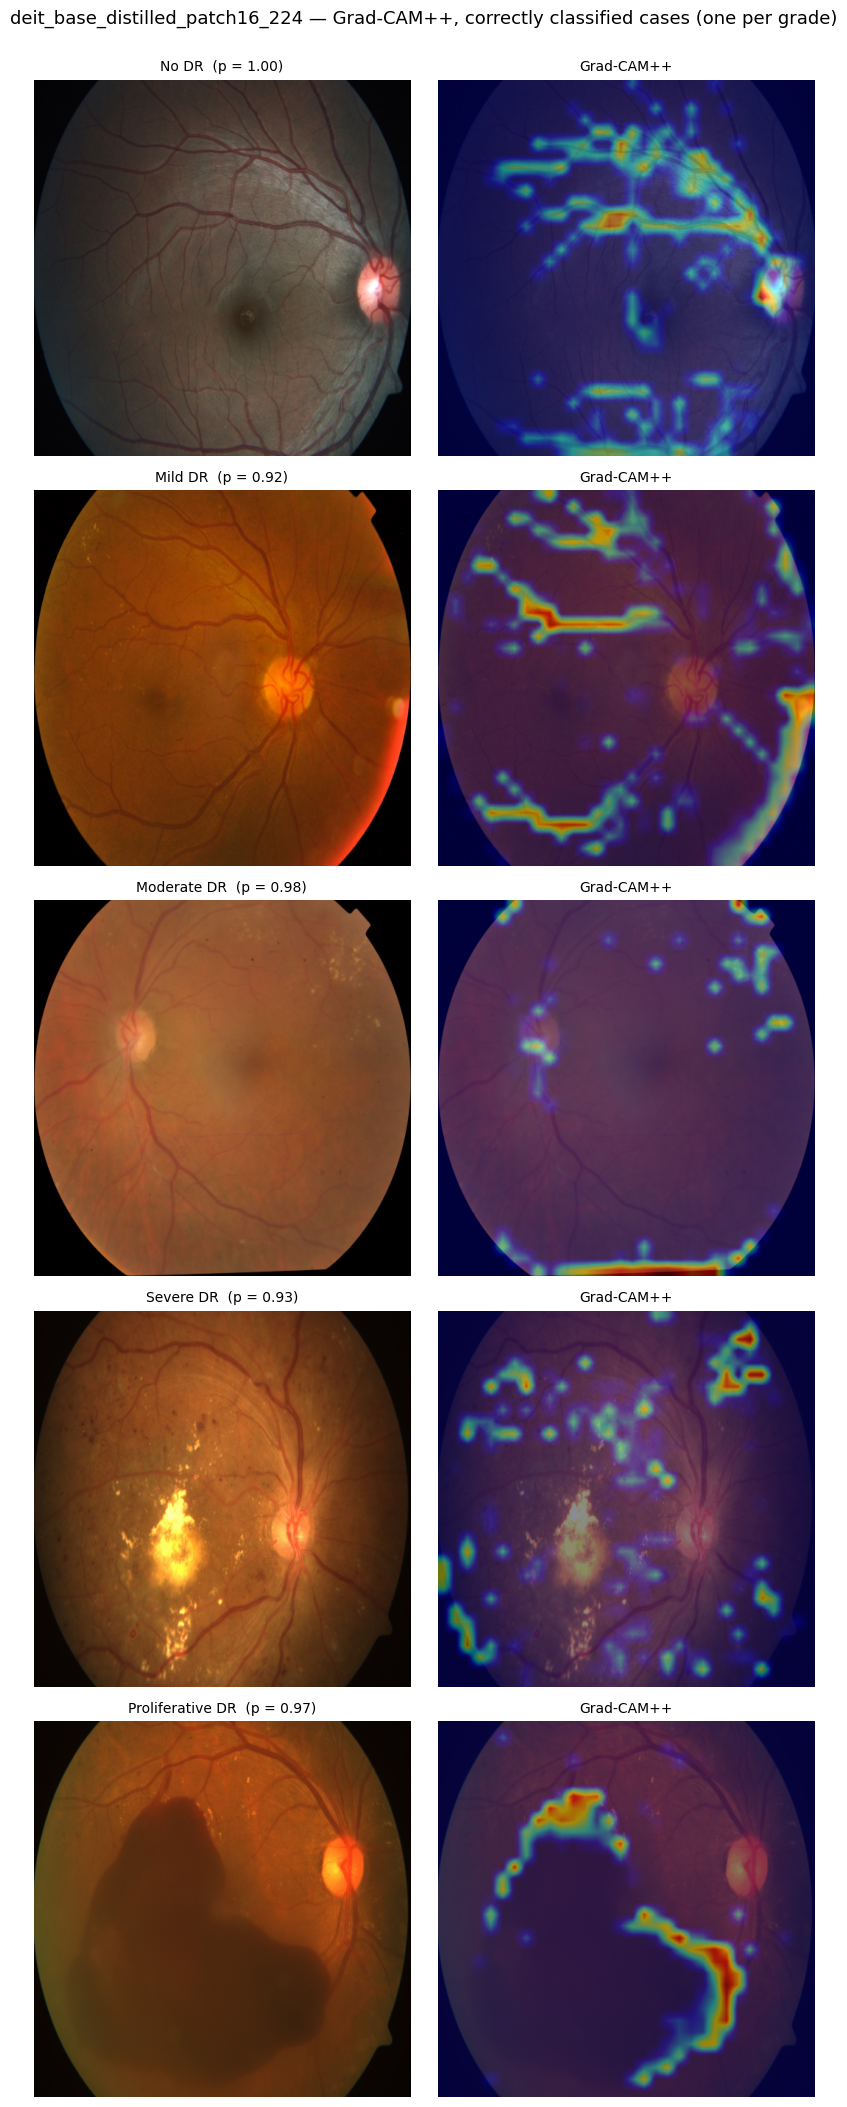

In [19]:
correct = [np.where((y_true == c) & (y_pred == c))[0] for c in range(CFG.N_CLASSES)]

fig, axes = plt.subplots(CFG.N_CLASSES, 2, figsize=(8.4, 4.2 * CFG.N_CLASSES))
for c in range(CFG.N_CLASSES):
    if len(correct[c]) == 0:
        for j in range(2):
            axes[c, j].text(.5, .5, f"No correct case\n{CLASS_NAMES[c]}", ha="center", va="center")
            axes[c, j].axis("off")
        continue

    i = int(correct[c][np.argmax(y_prob[correct[c], c])])
    img, cam, _, _ = cam_for_index(i)
    axes[c, 0].imshow(img)
    axes[c, 0].set_title(f"{CLASS_NAMES[c]}  (p = {y_prob[i, c]:.2f})", fontsize=10)
    axes[c, 1].imshow(overlay_cam(img, cam))
    axes[c, 1].set_title(CAM_LABEL, fontsize=10)
    for j in range(2):
        axes[c, j].axis("off")

plt.suptitle(f"{CFG.BACKBONE} — {CAM_LABEL}, correctly classified cases (one per grade)",
             y=1.001, fontsize=13)
plt.tight_layout()
plt.savefig(CFG.FIG_DIR / "cam_correct.png", dpi=180, bbox_inches="tight")
plt.show()

## Cell 20 — Figure 2: misclassifications

Maps on failures are more informative than on successes: they show whether the model looks at the
wrong region, or at the right region and still gets the grade wrong. Errors with the largest
magnitude (`|actual − predicted|`) are shown first.

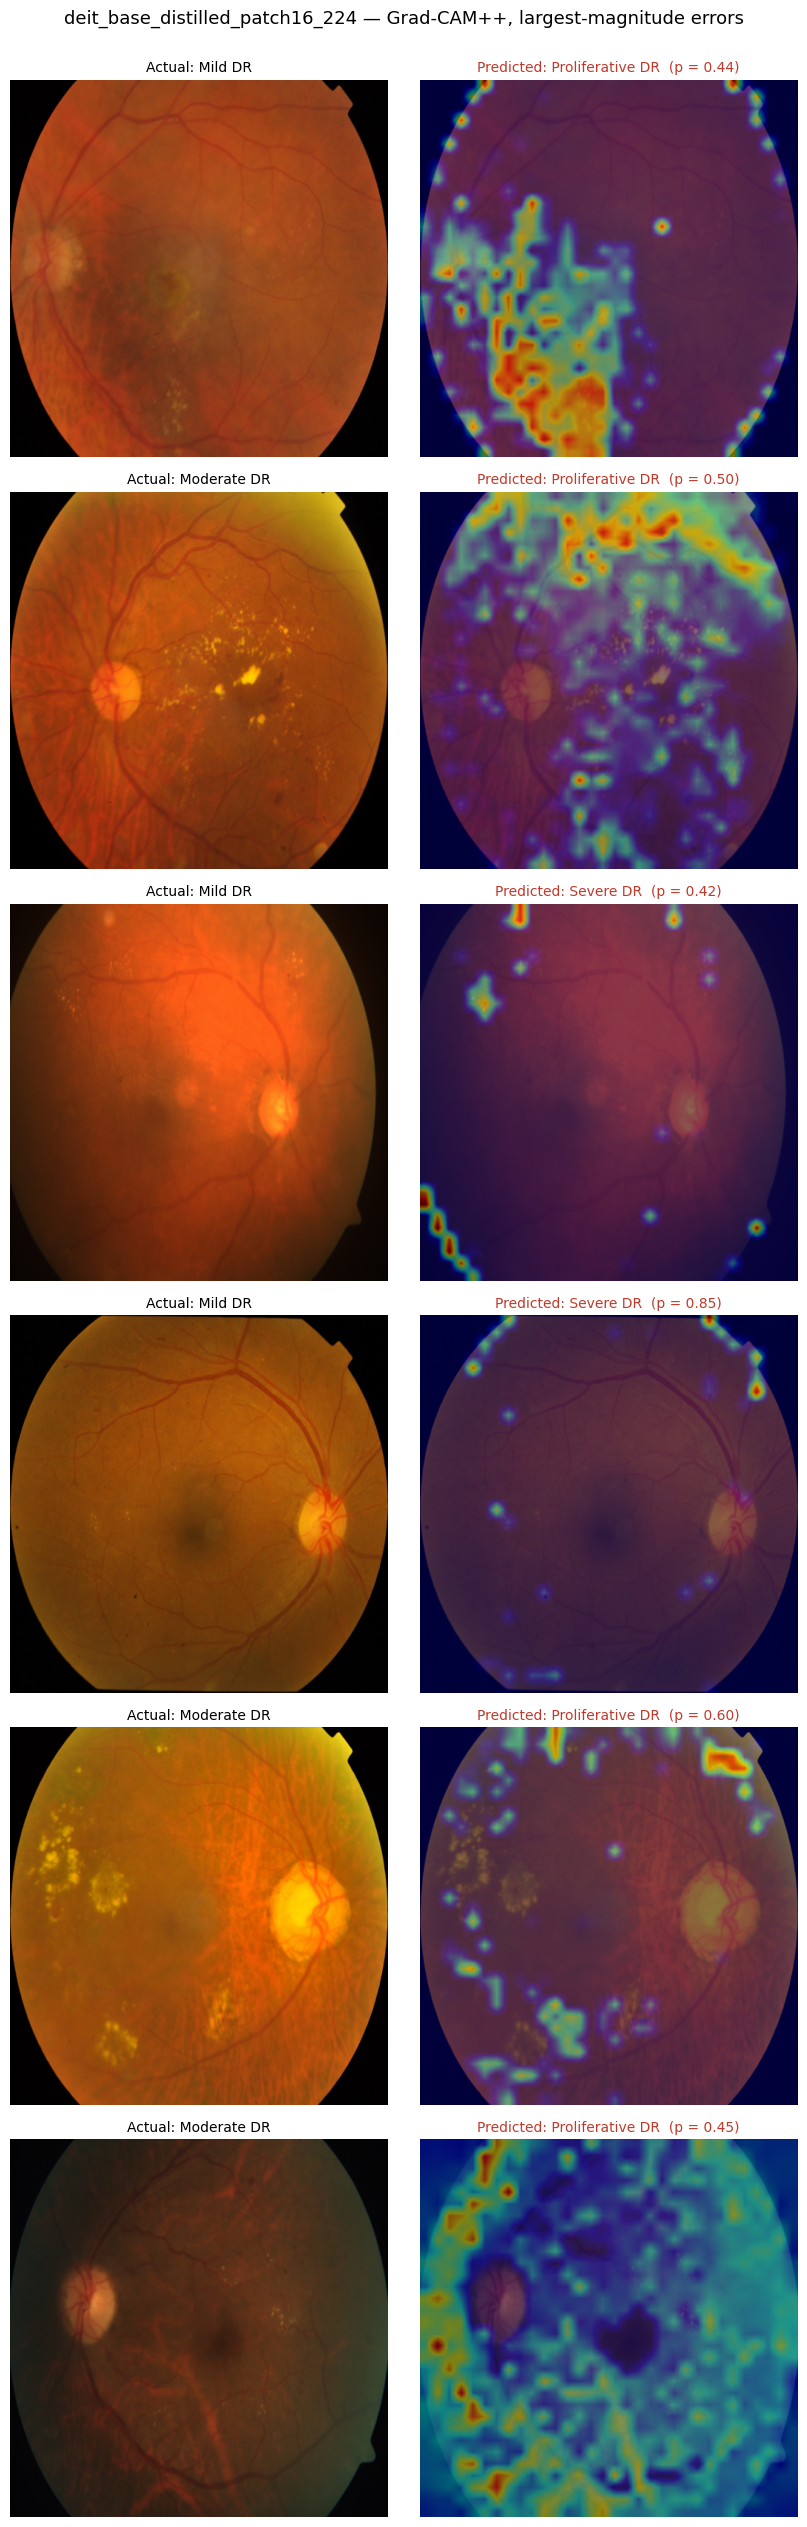

In [20]:
errors = np.where(y_true != y_pred)[0]
n_show = min(6, len(errors))

if n_show == 0:
    print("No misclassification.")
else:
    order = errors[np.argsort(-np.abs(y_true[errors] - y_pred[errors]), kind="stable")][:n_show]
    fig, axes = plt.subplots(n_show, 2, figsize=(8.6, 4.2 * n_show))
    axes = np.atleast_2d(axes)

    for r, i in enumerate(order):
        img, cam, yt, yp = cam_for_index(int(i))
        axes[r, 0].imshow(img)
        axes[r, 0].set_title(f"Actual: {CLASS_NAMES[yt]}", fontsize=10)
        axes[r, 1].imshow(overlay_cam(img, cam))
        axes[r, 1].set_title(f"Predicted: {CLASS_NAMES[yp]}  (p = {y_prob[i, yp]:.2f})",
                             fontsize=10, color="#c0392b")
        for j in range(2):
            axes[r, j].axis("off")

    plt.suptitle(f"{CFG.BACKBONE} — {CAM_LABEL}, largest-magnitude errors", y=1.001, fontsize=13)
    plt.tight_layout()
    plt.savefig(CFG.FIG_DIR / "cam_errors.png", dpi=180, bbox_inches="tight")
    plt.show()

## Cell 21 — Figure 3: class sensitivity on the same image

The same retina explained from the point of view of each of the 5 grades. A model that has learned a
notion of severity should shift its attention from one grade to another; identical maps would mean
the model does not discriminate spatially.

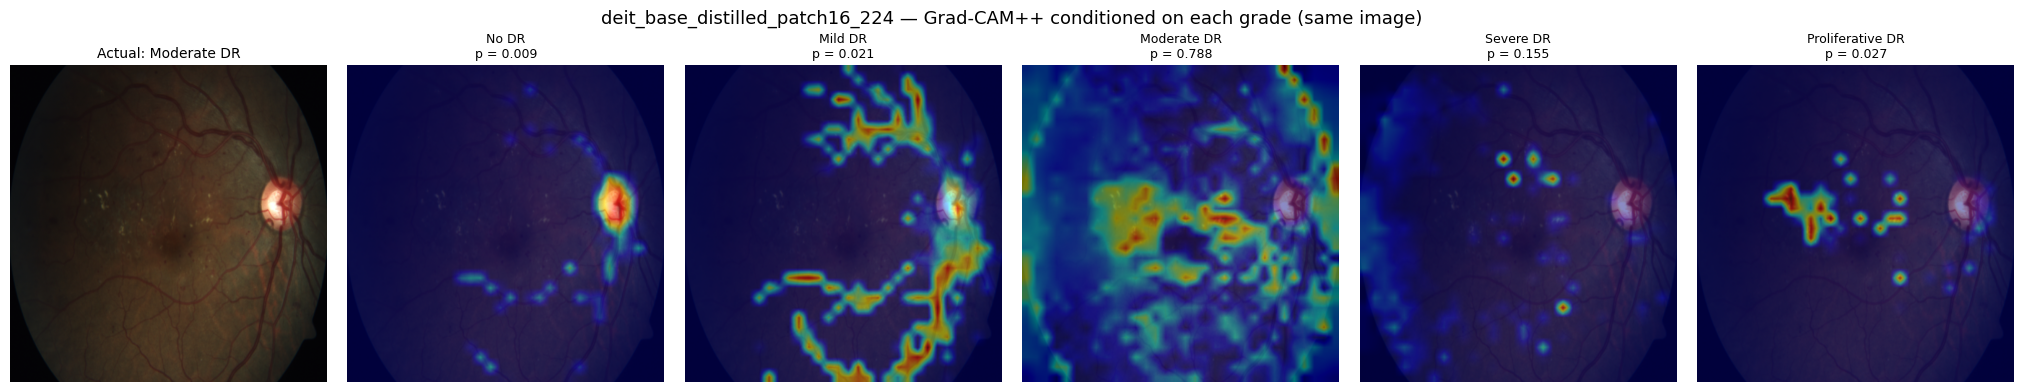

In [21]:
cand = np.where((y_true >= 2) & (y_true == y_pred))[0]
i = int(cand[0]) if len(cand) else int(np.argmax(y_true))

x, _ = ds_test[i]
x = x.unsqueeze(0).to(CFG.DEVICE)
img = denormalize(x[0])

fig, axes = plt.subplots(1, CFG.N_CLASSES + 1, figsize=(3.4 * (CFG.N_CLASSES + 1), 3.8))
axes[0].imshow(img); axes[0].axis("off")
axes[0].set_title(f"Actual: {CLASS_NAMES[y_true[i]]}", fontsize=10)

for c in range(CFG.N_CLASSES):
    cam_c = cam_engine(x, class_idx=c)[0]
    axes[c + 1].imshow(overlay_cam(img, cam_c)); axes[c + 1].axis("off")
    axes[c + 1].set_title(f"{CLASS_NAMES[c]}\np = {y_prob[i, c]:.3f}", fontsize=9)

plt.suptitle(f"{CFG.BACKBONE} — {CAM_LABEL} conditioned on each grade (same image)",
             y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(CFG.FIG_DIR / "cam_per_class.png", dpi=180, bbox_inches="tight")
plt.show()

cam_engine.remove()   # detach the hooks

## Cell 22 — Saving the results

`metrics.json` holds the whole run: configuration, preprocessing inherited from notebook `00`,
split fingerprints, epoch-by-epoch history, test metrics, bootstrap CIs, per-class metrics,
referable DR and confusion matrix. The file is self-contained.

Two identical copies are written: `/kaggle/working/metrics.json` and
`results/metrics/<MODEL_NAME>.json`, the file name expected by `08_model_comparison`.

In [22]:
best_row = hist.loc[hist["epoch"] == best_epoch].iloc[0]

metrics = {
    "run": {"model": CFG.MODEL_NAME, "backbone": CFG.BACKBONE, "family": CFG.FAMILY,
            "architecture": "timm default, num_classes=5", "classifier": classifier_name,
            "seed": CFG.SEED, "img_size": CFG.IMG_SIZE,
            "select_on": CFG.SELECT_ON, "cam_method": CFG.CAM_METHOD,
            "cam_layer": CFG.CAM_LAYER,
            "n_params_total": int(n_tot), "n_params_classifier": int(n_clf),
            "n_features": int(model.num_features),
            "timestamp": time.strftime("%Y-%m-%d %H:%M:%S")},
    "data": {"prep_dir": str(prep_dir), "preprocessing": prep_cfg, "split_sha1": split_sha1},
    "split": {"train": len(df_train), "val": len(df_val), "test": len(df_test),
              "test_class_counts": np.bincount(y_true, minlength=CFG.N_CLASSES).tolist()},
    "training": {"epochs_run": int(len(hist)), "best_epoch": int(best_epoch),
                 "minutes": round(float(train_minutes), 2),
                 "best_val_loss": float(stopper.best),
                 "val_qwk_at_best": float(best_row["val_qwk"]),
                 "val_acc_at_best": float(best_row["val_acc"]),
                 "history": hist.to_dict("records")},
    "test": {"n": int(len(y_true)), "loss": float(test_loss),
             "accuracy": float(acc), "f1_macro": float(f1_macro),
             "qwk": float(qwk), "kappa_linear": float(kappa_lin),
             "auc_ovr_macro": float(auc_ovr_macro), "auc_ovr_weighted": float(auc_ovr_weighted),
             "auc_micro": float(auc_micro),
             "auc_per_class": [float(a) for a in auc_per_class]},
    "bootstrap_ci95": boot,
    "averages": {k: {kk: float(vv) for kk, vv in v.items()}
                 for k, v in agg.to_dict("index").items()},
    "per_class": per_class.to_dict("records"),
    "classification_report": cls_report,
    "referable_dr": {k: float(v) for k, v in referable.items()},
    "confusion_matrix": cm.tolist(),
    "class_names": CLASS_NAMES,
    "config": {k: str(v) for k, v in vars(CFG).items() if not k.startswith("_")},
}

for out_json in (CFG.WORK_DIR / "metrics.json", CFG.METRIC_DIR / f"{CFG.MODEL_NAME}.json"):
    with open(out_json, "w") as f:
        json.dump(metrics, f, indent=2, ensure_ascii=False)

summary = pd.DataFrame([
    ["Multiclass accuracy (%)",       f"{acc*100:.2f}"],
    ["QWK",                           f"{qwk:.4f}"],
    ["F1 macro",                      f"{f1_macro:.4f}"],
    ["AUC (OvR macro)",               f"{auc_ovr_macro:.4f}"],
    ["Macro sensitivity (%)",         f"{macro['sensitivity']*100:.2f}"],
    ["Referable DR — sensitivity (%)", f"{referable['sensitivity']*100:.2f}"],
    ["Referable DR — specificity (%)", f"{referable['specificity']*100:.2f}"],
    ["Epochs run",                    f"{len(hist)} (best: {best_epoch})"],
], columns=["Metric", f"{CFG.BACKBONE} (s{CFG.SEED})"])

print("=" * 80)
print(f"{CFG.BACKBONE} (timm, unmodified) — APTOS-2019, test n={len(y_true)}, seed {CFG.SEED}")
print("=" * 80)
print(summary.to_string(index=False))
print("=" * 80)
summary.to_csv(_artifact("final_summary.csv"), index=False)

print()
for f in sorted(p for p in CFG.WORK_DIR.rglob("*") if p.is_file()):
    print(f"{str(f.relative_to(CFG.WORK_DIR)):<55} {f.stat().st_size / 1024:9.1f} KB")

deit_base_distilled_patch16_224 (timm, unmodified) — APTOS-2019, test n=366, seed 42
                        Metric deit_base_distilled_patch16_224 (s42)
       Multiclass accuracy (%)                                 79.23
                           QWK                                0.9049
                      F1 macro                                0.6466
               AUC (OvR macro)                                0.9513
         Macro sensitivity (%)                                 67.46
Referable DR — sensitivity (%)                                 96.76
Referable DR — specificity (%)                                 98.34
                    Epochs run                          12 (best: 9)

__notebook__.ipynb                                         6119.0 KB
checkpoints/deit_base_distilled_patch16_224_s42.pth      337734.4 KB
metrics.json                                                 11.0 KB
results/figures/deit_base_distilled_patch16_224/cam_correct.png    4362.1 KB
results/f